In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBRegressor
import matplotlib.pyplot as plt



In [2]:
df = pd.read_csv(r"D:\Data Analytics & Data Science\NetMax Technologies\cardekho.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,5.0


In [3]:
# drop unnecessary columns
df.drop(["name"], axis=1, inplace=True)

In [4]:
# check for missing values
df.isnull().sum()

year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
seats            221
dtype: int64

In [5]:
# fill missing values with mean and modefor numerical columns
df["engine"] = df["engine"].fillna(df["engine"].mean())
df["mileage"] = df["mileage"].fillna(df["mileage"].mean())
df["seats"] = df["seats"].fillna(df["seats"].mode()[0])

In [6]:
df.head()   

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,5.0


In [7]:
# handling categorical variables using Label Encoding
label_encoder = LabelEncoder()

df["fuel"] = label_encoder.fit_transform(df["fuel"])
df["seller_type"] = label_encoder.fit_transform(df["seller_type"])
df["transmission"] = label_encoder.fit_transform(df["transmission"])
df["owner"] = label_encoder.fit_transform(df["owner"])

In [8]:
# feature selection
x= df.drop("selling_price", axis=1)
y= df["selling_price"]

In [9]:
# model selection and training
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,seats
0,2014,450000,145500,1,1,1,0,23.40,1248.0,5.0
1,2014,370000,120000,1,1,1,2,21.14,1498.0,5.0
2,2006,158000,140000,3,1,1,4,17.70,1497.0,5.0
3,2010,225000,127000,1,1,1,0,23.00,1396.0,5.0
4,2007,130000,120000,3,1,1,0,16.10,1298.0,5.0


In [11]:
# fitting the model with out scaling and hyperparameter tuning
random_forest_model = RandomForestRegressor(max_depth=10, n_estimators=100, random_state=42)
random_forest_model.fit(x_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
# evaluate the model
y_pred_random_forest = random_forest_model.predict(x_test)
r2_random_forest = r2_score(y_test, y_pred_random_forest)
print("Random Forest R2 Score:", r2_random_forest)

Random Forest R2 Score: 0.9470029477554129


In [14]:
# now let's try scaling the features and see if it improves the model performance


scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# fit the model with scaled features
random_forest_model_scaled = RandomForestRegressor(max_depth=10, n_estimators=100, random_state=42)
random_forest_model_scaled.fit(x_train_scaled, y_train)

# evaluate the scaled model
y_pred_random_forest_scaled = random_forest_model_scaled.predict(x_test_scaled)
r2_random_forest_scaled = r2_score(y_test, y_pred_random_forest_scaled)
print("Random Forest R2 Score (Scaled):", r2_random_forest_scaled)

Random Forest R2 Score (Scaled): 0.9470143448439002


In [15]:
# now using XGBoost Regressor with hyperparameter tuning
best_params = {
    'n_estimators': [100,150, 200, 250, 300],
    'max_depth': [3, 5, 7, 9, 12],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}
model = XGBRegressor(random_state=42)

grid_search = GridSearchCV(estimator=model, 
                           param_grid=best_params, 
                           cv=5, 
                           n_jobs=-1, 
                           verbose=1)

grid_search.fit(x_train_scaled, y_train)

Fitting 5 folds for each of 125 candidates, totalling 625 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 150, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [20]:
grid_search_best_model = grid_search.best_estimator_

In [21]:
y_pred_best_model = grid_search_best_model.predict(x_test_scaled)
r2_best_model = r2_score(y_test, y_pred_best_model)
print("Best Model R2 Score:", r2_best_model)

Best Model R2 Score: 0.9179887771606445


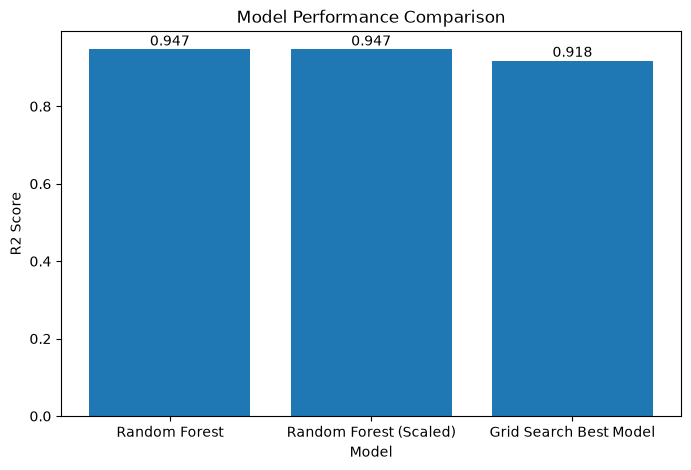

In [26]:
# plotting the r2 scores for comparison with values of r2 on the top of the bars
plt.figure(figsize=(8, 5))
plt.bar(['Random Forest', 'Random Forest (Scaled)', 'Grid Search Best Model'], [r2_random_forest, r2_random_forest_scaled, r2_best_model])
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.title('Model Performance Comparison')
for i, v in enumerate([r2_random_forest, r2_random_forest_scaled, r2_best_model]):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')
plt.show()